# Eval analysis

### imports

In [1]:
import logging
from dotenv import load_dotenv
from evals import Dataset
from evals.metrics import CollectMetrics
import warnings
from huggingface_hub.utils import _http
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from plotly import subplots
import pandas as pd
from tqdm import tqdm
logger = logging.getLogger(__name__)

logging.getLogger(__name__).setLevel(logging.DEBUG)
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)


warnings.filterwarnings(
    "ignore",
    message=".*UNEXPECTED.*",
    #message = ".*Warning.*",
    category=UserWarning,
    module="transformers.modeling_utils"  
)

load_dotenv()

True

### Loading Data

In [2]:
def load_results(dataset_name):
    ds = Dataset(dataset_name)
    cm = CollectMetrics()
    eval_res = ds.load_evaluation_results()
    all_eval_runs = cm.organize_runs_by_type(eval_res)
    coll_res = ds.load_results()
    all_collected_res = cm.organize_runs_by_type(coll_res)
    #DeepEval
    logger.info("Collecting DeepEval metrics...")
    deepeval_obs = []
    for runs in tqdm(all_eval_runs.values()):
        deepeval_obs.extend(cm.collect_deepeval_metrics(runs))
    #bert metrics
    logger.info("Collecting BERT metrics...")
    berts = []
    for runs in tqdm(all_eval_runs.values()):
        berts.extend(cm.collect_berts(runs))
    #Resource metrics
    logger.info(f'Collecting resource metrics...')
    gathered_res = ds.load_results()
    resource_obs = cm.collect_resource_metrics(list(gathered_res.values()))

    logger.info("Merging metrics into DataFrame...")
    df_de = pd.DataFrame([dp.model_dump() for dp in deepeval_obs])
    df_brt = pd.DataFrame([bert.model_dump() for bert in berts])
    df_rm = pd.DataFrame([rm.model_dump() for rm in resource_obs])
    drop = ["eval_run_id", 
            "name",
            #"query_id", "session_id", 
            ]
    on = ["llm_model", "dataset_name", 
            "query_id", "session_id", "agent_type",
            "session", "session_name"]

    df = pd.merge(df_de.drop(columns=drop, errors = "ignore"), df_rm.drop(columns=drop, errors = "ignore"), on = on,)
                                                                                                                
    df = pd.merge(df, df_brt.drop(columns=drop, errors = "ignore"), on = on)
    return df

In [3]:
try:
    df_thrd = load_results("THRD-2021-163881")
except Exception as e:
    print(f"Error loading THRD results: {e}")

try:
    df_tosl = load_results("TOSL-2024-125319-MIN")
except Exception as e:
    print(f"Error loading TOSL results: {e}")

INFO:__main__:Collecting DeepEval metrics...
100%|██████████| 6/6 [00:00<00:00, 3924.19it/s]
INFO:__main__:Collecting BERT metrics...
100%|██████████| 6/6 [01:06<00:00, 11.05s/it]
INFO:__main__:Collecting resource metrics...
INFO:__main__:Merging metrics into DataFrame...
INFO:__main__:Collecting DeepEval metrics...
100%|██████████| 6/6 [00:00<00:00, 6230.71it/s]
INFO:__main__:Collecting BERT metrics...
100%|██████████| 6/6 [01:00<00:00, 10.16s/it]
INFO:__main__:Collecting resource metrics...
INFO:__main__:Merging metrics into DataFrame...


In [4]:
df = pd.concat([df_thrd, df_tosl], ignore_index=True)

In [6]:
df.head()

,dataset_name,query_id,session_id,session,session_name,llm_model,agent_type,question_type,correctness,relevancy,...,total_tokens,llm_calls,bert_precision,bert_recall,bert_f1,s_bert_similarity,actual_output,expected_output,embedded_actual_output,embedded_expected_output
0,THRD-2021-163881,82d6385b-3f42-4c89-8df6-82cea426f45a,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,factual,1.0,1.0,...,36225,2,0.629391,0.760249,0.688659,0.917468,"Ja, det er tatt forbehold i salgsoppgaven og k...",- Kjøpskontrakten inneholder en «som den er»-k...,"[0.004865377, 0.008909141, -0.003945247, -0.05...","[0.013837026, 0.016975842, -0.0038165622, -0.0..."
1,THRD-2021-163881,4839e2f2-4717-4f33-b04f-be81496b2648,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,factual,1.0,1.0,...,21504,1,0.610427,0.771043,0.681398,0.905637,Her er en beskrivelse av aktørene i saken og d...,- Anders og Berit Kristiansen: saksøkere (kjøp...,"[-0.0039394367, 0.0054898914, 0.007177732, -0....","[-0.013774939, -0.0079543, -0.0017583347, -0.0..."
2,THRD-2021-163881,070f570b-f9d0-454f-90ca-84f66ede1a31,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,factual,0.6,1.0,...,12064,1,0.659326,0.743674,0.698964,0.938199,"Kjøperne, Anders og Berit Kristiansen, har mot...",- Eierens opplysningsskjema: selger opplyste o...,"[0.0002993953, 0.01868615, -0.0101048965, -0.0...","[0.004011874, 0.025300551, -0.009952226, -0.04..."
3,THRD-2021-163881,335b247f-0a2b-4eef-85f8-5cc0e2c6a2e2,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,factual,0.6,1.0,...,25623,2,0.621907,0.748193,0.679230,0.939552,Basert på de tilgjengelige dokumentene er følg...,- Eneste formelt reklamerte mangel (per mars 2...,"[-0.009208715, 0.012256192, -0.006481587, -0.0...","[-0.011796225, 0.008586926, -0.010823273, -0.0..."
4,THRD-2021-163881,f3f226bb-eb5c-4b87-8d96-dfa425614f42,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,summary,0.8,1.0,...,12911,2,0.683211,0.747082,0.713721,0.955617,Anders og Berit Kristiansen kjøpte eiendommen ...,- Anders og Berit Kristiansen kjøpte Fjellveie...,"[0.0013216397, 0.016857985, -0.009796431, -0.0...","[-0.005734375, 0.016356306, 0.0032262322, -0.0..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   dataset_name              652 non-null    object        
 1   query_id                  652 non-null    object        
 2   session_id                652 non-null    object        
 3   session                   652 non-null    int64         
 4   session_name              652 non-null    object        
 5   llm_model                 652 non-null    object        
 6   agent_type                652 non-null    object        
 7   question_type             652 non-null    object        
 8   correctness               652 non-null    float64       
 9   relevancy                 652 non-null    float64       
 10  completeness              400 non-null    float64       
 11  success                   652 non-null    bool          
 12  starttime             

In [8]:
def standardize_model_names(df):
    df.loc[df["llm_model"] == "qwen_Qwen/Qwen3-Next-80B-A3B-Instruct" , "llm_model"] = "Qwen3-Next-80B-A3B-Instruct"
    df.loc[df["llm_model"] == "qwen_Qwen/Qwen3.5-397B-A17B" , "llm_model"] = "Qwen3.5-397B-A17B"
    df.loc[df["llm_model"] == "zai_zai-org/GLM-5" , "llm_model"] = "GLM-5"
    df.loc[df["llm_model"] == "google_gemini-2.5-flash" , "llm_model"] = "gemini-2.5-flash"
    df.loc[df["llm_model"] == "google_gemini-2.5-pro" , "llm_model"] = "gemini-2.5-pro"

    models_to_keep = ["Qwen3.5-397B-A17B", "GLM-5", "gemini-2.5-flash", "gemini-2.5-pro"]
    df = df[df["llm_model"].isin(models_to_keep)]
standardize_model_names(df)
df["llm_model"].value_counts()

llm_model
gemini-2.5-flash     342
Qwen3.5-397B-A17B    184
gemini-2.5-pro       126
Name: count, dtype: int64

In [ ]:
prob_vars = ["correctness", "relevancy", "completeness"]
for var in prob_vars:
    getattr(df, var).max

## EDA

### Deep Eval metrics
Correctness, Relevancy & Completeness

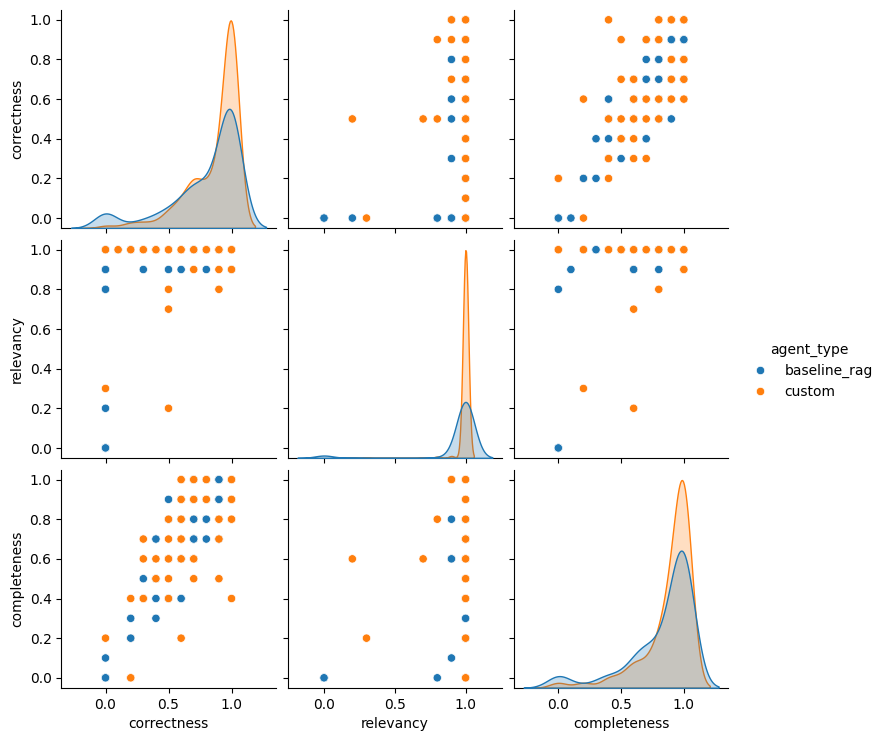

In [9]:
sns.pairplot(df[["correctness", "relevancy", "completeness", "llm_model", "agent_type"]], hue = "agent_type")
#plt.savefig(f'../thesis/figures/pairplot_deep_eval.png')

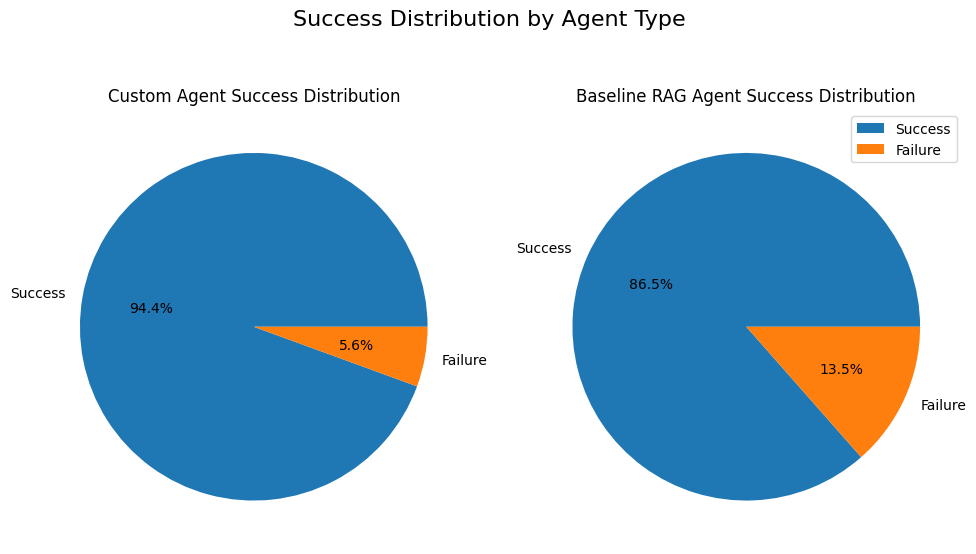

In [10]:
fig,ax = plt.subplots(figsize=(10,10),nrows = 1, ncols = 2)
ax[0].pie(df.loc[df["agent_type"] == "custom", "success"].value_counts(), labels = ["Success", "Failure"], autopct='%1.1f%%')
ax[0].set_title("Custom Agent Success Distribution")
ax[1].pie(df.loc[df["agent_type"] == "baseline_rag", "success"].value_counts(), labels = ["Success", "Failure"], autopct='%1.1f%%')
ax[1].set_title("Baseline RAG Agent Success Distribution")

plt.suptitle("Success Distribution by Agent Type", y = 0.8, fontsize = 16)
plt.legend()
plt.tight_layout()
#plt.savefig(f'../thesis/figures/success_distribution.png')

<Axes: xlabel='agent_type', ylabel='completeness'>

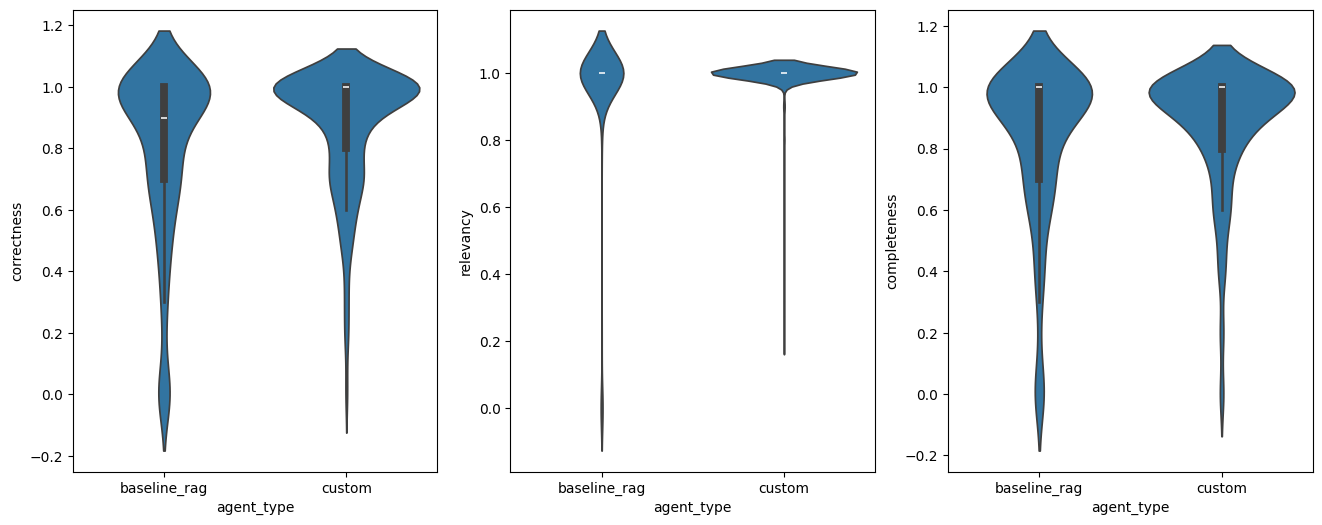

In [11]:
fig, ax = plt.subplots(figsize=(16, 6), ncols=3, nrows=1)
sns.violinplot(df, x = "agent_type", y = "correctness", ax=ax[0])
sns.violinplot(df, x = "agent_type", y = "relevancy", ax=ax[1])
sns.violinplot(df, x = "agent_type", y = "completeness", ax=ax[2])

### Bert metrics

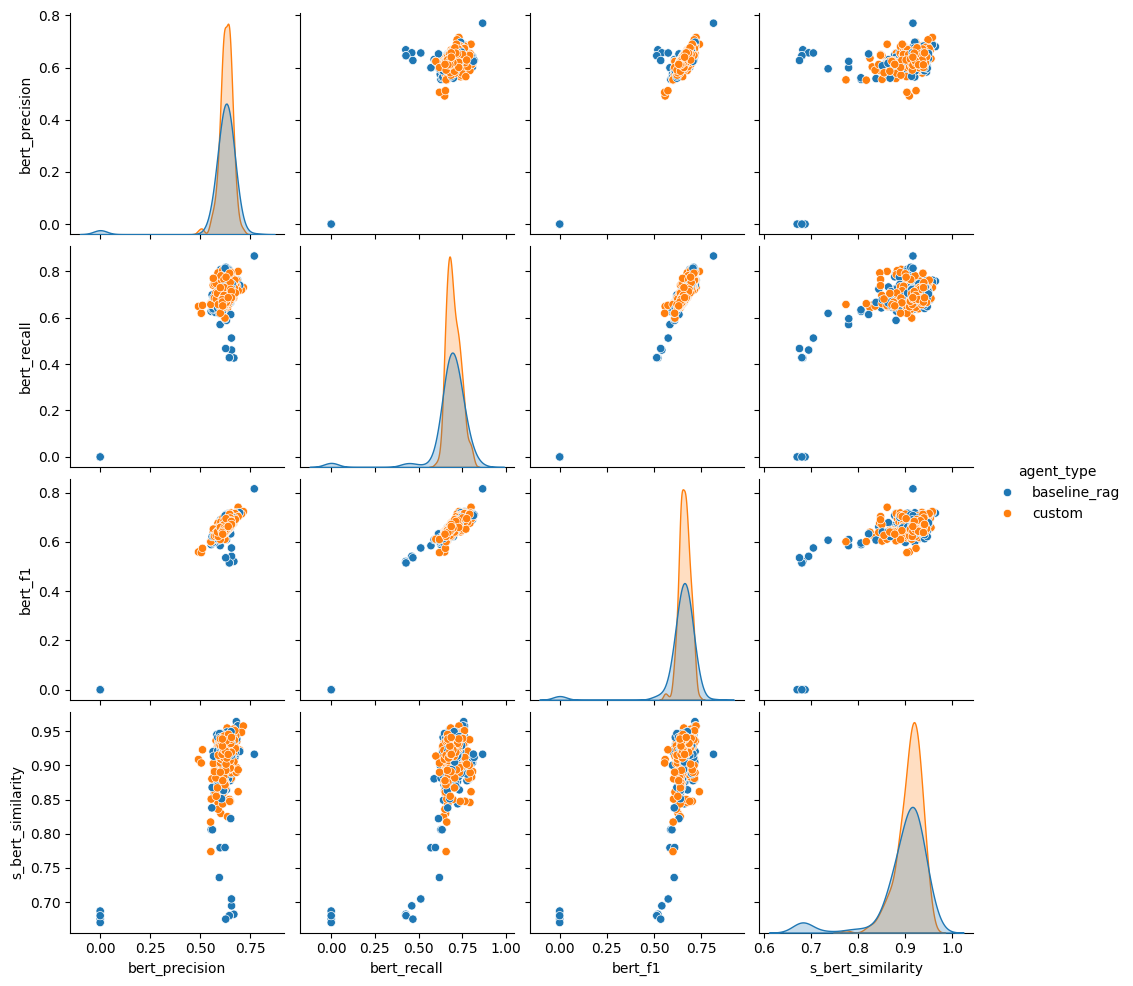

In [43]:
sns.pairplot(df[["bert_precision", "bert_recall", "bert_f1", "s_bert_similarity","llm_model", "agent_type"]], hue = "agent_type")
#plt.savefig(f'../thesis/figures/pairplot_bert.png')

### Resource metrics
Token counts and time coutns

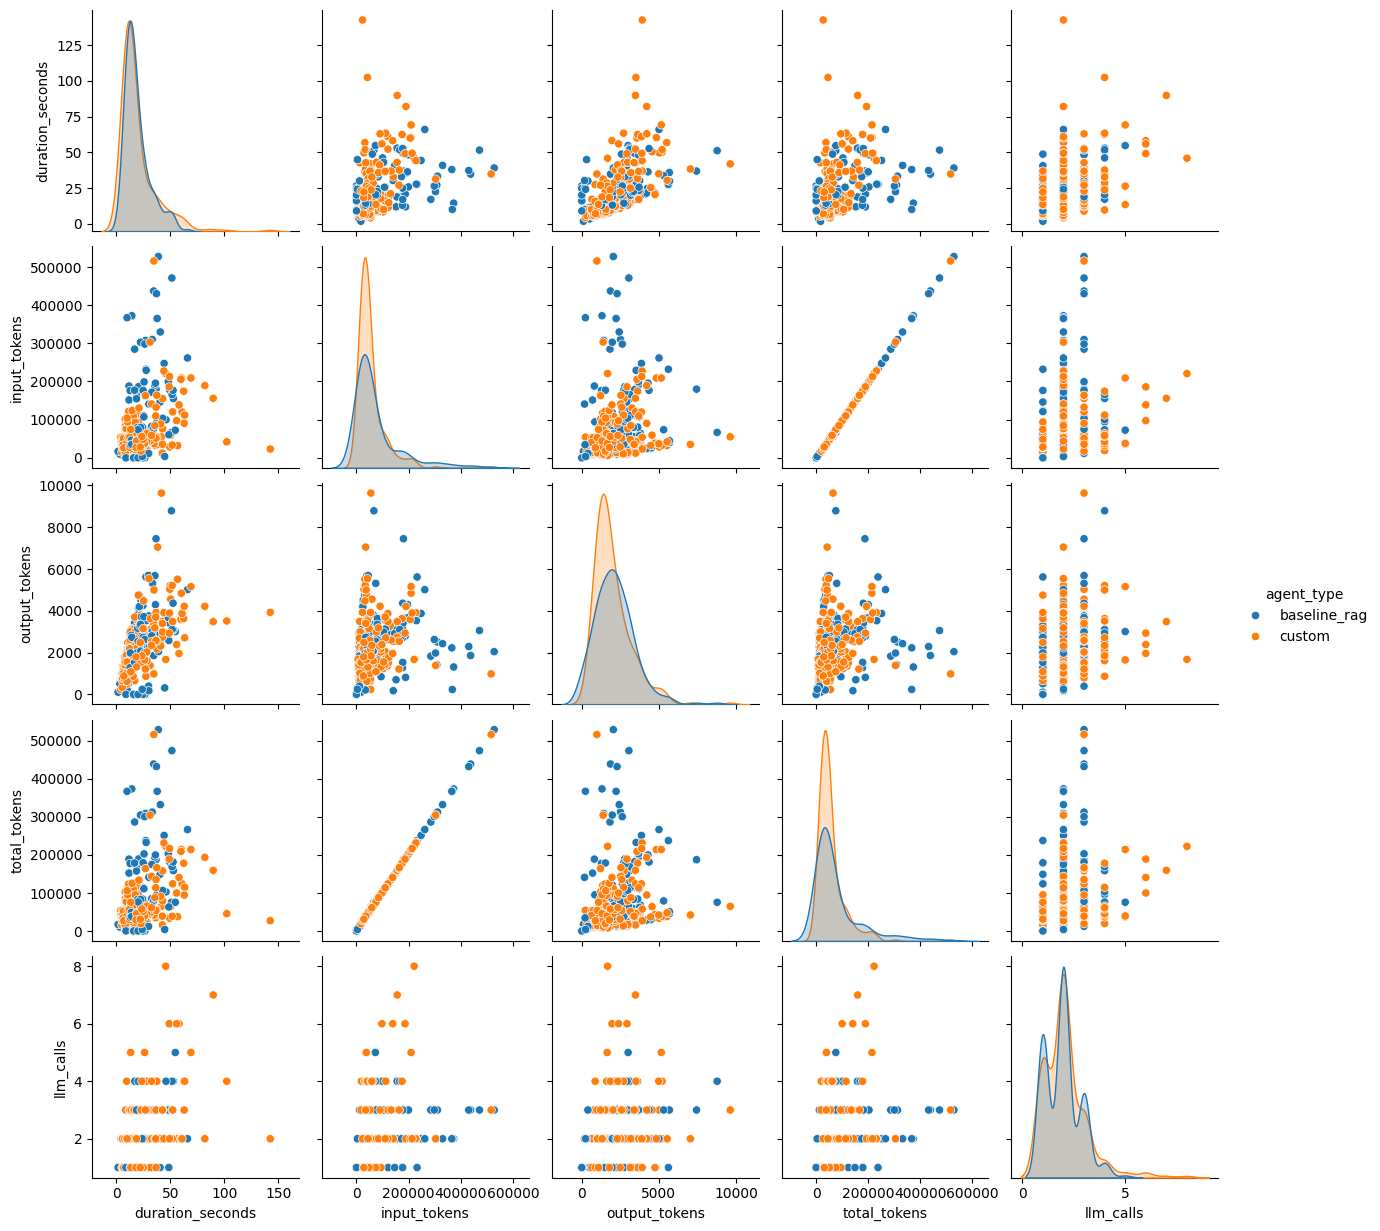

In [44]:
sns.pairplot(df[["duration_seconds", "input_tokens", "output_tokens", "total_tokens" , "llm_calls", "llm_model", "agent_type"]], hue = "agent_type")
#plt.savefig(f'../thesis/figures/pairplot_resource.png')

### Combined
Deep eval, bert & resource

<Axes: xlabel='duration_seconds', ylabel='correctness'>

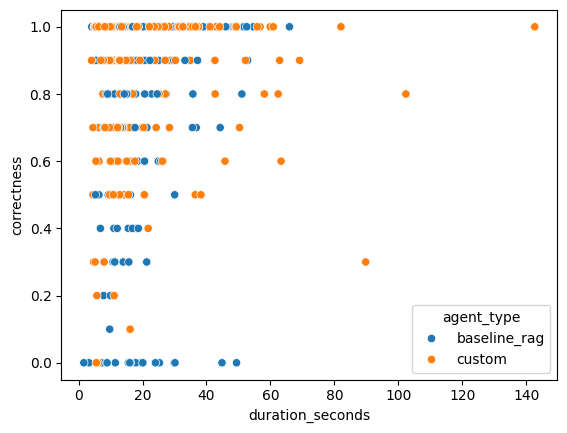

In [45]:
sns.scatterplot(df, x = "duration_seconds", y = "correctness", hue = "agent_type",)
                

## Statistical Modeling

In [51]:
import numpy as np
from scipy import stats 

from evals.models import DeepEvalObservation

class StatisticalMetrics:
    def __init__(self, significance_level: float = 0.05):
        self.significance_level = significance_level

    def check_normality(self, values: list[float] | np.ndarray):
        """
        Performs Shapiro-Wilk test for normality.
        """
        result = stats.shapiro(values)
        is_normal = result.pvalue > self.significance_level
        status = "✅ Normal distribution" if is_normal else "❌ Not normal distribution"
        print(f"{status} (p={result.pvalue:.2e})")
        return is_normal

    def mann_whitney_u_test(self, group_a: list[float] | np.ndarray, group_b: list[float] | np.ndarray):
        """
        Non-parametric alternative to Independent T-test (for 2 groups).
        Does not assume normality.
        """
        u_stat, p = stats.mannwhitneyu(group_a, group_b, alternative='greater')
        print(f"\n--- Mann-Whitney U Test (Non-parametric T-test) ---")
        print(f"U-statistic: {u_stat:.2f}, p-value: {p:.4e}")
        
        if p < self.significance_level:
            print(f"✅ Group A is significantly greater than Group B (p < {self.significance_level})")
        else:
            print(f"❌ No significant difference (p >= {self.significance_level})")
        return p

    def kruskal_wallis_test(self, *groups: list[float] | np.ndarray):
        """
        Non-parametric alternative to One-way ANOVA (for 3+ groups).
        Tests if at least one group comes from a different distribution.
        """
        h_stat, p = stats.kruskal(*groups)
        print(f"\n--- Kruskal-Wallis Test (Non-parametric ANOVA) ---")
        print(f"H-statistic: {h_stat:.2f}, p-value: {p:.4e}")
        
        if p < self.significance_level:
            print(f"✅ Significant difference exists between at least two groups.")
        else:
            print(f"❌ No significant difference between the groups.")
        return p

    def wilcoxon_signed_rank_test(self, before: list[float], after: list[float]):
        """
        Non-parametric alternative to Paired T-test.
        Use this if the '0-1 values' are from the same subjects/items at different times.
        """
        stat, p = stats.wilcoxon(before, after, alternative='greater')
        print(f"\n--- Wilcoxon Signed-Rank Test (Paired) ---")
        print(f"Statistic: {stat:.2f}, p-value: {p:.4e}")
        return p
    def t_test(self, custom_eval: list[float] | np.ndarray, comparison_eval: list[float] | np.ndarray):
        t_stat, p = stats.ttest_ind(custom_eval, comparison_eval, equal_var=False, alternative='greater')
        print(f"Custom vs. Comparison: t={t_stat:.2f}, p={p:.4f}")
        if p < self.significance_level:
            print("✅ Custom beats Comparison (p<0.05).")
        else:
            print("❌ No significant difference (p>=0.05).")

def filter_evals(
                dataframe : pd.DataFrame,
                agent_type: str, 
                 metric: str = "correctness", 
                 llm_model: list[str] | None = None,
                 ):
    if llm_model is not None:
        return dataframe.loc[(dataframe["agent_type"] == agent_type) & (dataframe["llm_model"].isin(llm_model)), [metric]].values.flatten()  
    return dataframe.loc[dataframe["agent_type"] == agent_type, [metric]].values.flatten()

In [52]:
from collections import Counter
df["agent_type"].value_counts()

agent_type
custom          341
baseline_rag    311
Name: count, dtype: int64

### Correctness

❌ Not normal distribution (p=8.84e-24)


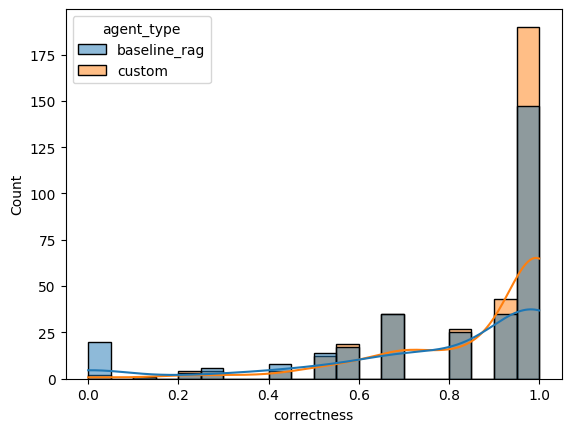

In [54]:
StatisticalMetrics().check_normality(filter_evals(df, "custom", "correctness"))
sns.histplot(df, x = "correctness", hue = "agent_type", kde = True, bins = 20)
plt.savefig(f'../thesis/figures/correctness_distribution.png')

In [ ]:
#Since not normally distributed, we use Mann-Whitney U test (non-parametric alternative to T-test)
sm = StatisticalMetrics()
metric = "correctness"
custom_data = filter_evals(agent_type="custom", 
                                metric=metric,
                                dataframe=df,
                                )
rag_data =  filter_evals(agent_type="baseline_rag",
                                metric=metric, 
                                dataframe=df,
                                )

#sm.check_normality(custom_data)
#sm.t_test(custom_eval=custom_data, comparison_eval=rag_data)
sm.mann_whitney_u_test(group_a=custom_data, group_b=rag_data)


--- Mann-Whitney U Test (Non-parametric T-test) ---
U-statistic: 31228.50, p-value: 3.9779e-04
✅ Group A is significantly greater than Group B (p < 0.05)


np.float64(0.00039779083266644315)

### Self consistency

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   dataset_name              652 non-null    object        
 1   query_id                  652 non-null    object        
 2   session_id                652 non-null    object        
 3   session                   652 non-null    int64         
 4   session_name              652 non-null    object        
 5   llm_model                 652 non-null    object        
 6   agent_type                652 non-null    object        
 7   question_type             652 non-null    object        
 8   correctness               652 non-null    float64       
 9   relevancy                 652 non-null    float64       
 10  completeness              400 non-null    float64       
 11  success                   652 non-null    bool          
 12  starttime             

In [ ]:
def pairwise_cosine_similarities(embeddings):
    """
    Tar inn en liste av embeddings (liste av list[float] eller array)
    Returnerer en matrise med alle pairwise cosine similarities
    """
    emb = np.array(embeddings, dtype=float)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    normalized = emb / norms                     # L2-normaliser
    sim_matrix = normalized @ normalized.T       # alle mot alle
    return sim_matrix

def self_consistency_score(embeddings, method="mean"):
    """
    Regner ut en self-consistency score for en gruppe embeddings.
    
    method:
      - 'mean'     → gjennomsnitt av alle unike pairwise similarities (vanligst)
      - 'min'      → den laveste pairwise similarity (strengeste)
      - 'median'   → median av pairwise similarities
    """
    if len(embeddings) < 2:
        return 1.0  # kun én embedding → perfekt consistency
    
    sim_matrix = pairwise_cosine_similarities(embeddings)
    
    # Ta bare upper triangle (uten diagonal)
    triu_idx = np.triu_indices_from(sim_matrix, k=1)
    pairwise_sims = sim_matrix[triu_idx]
    
    if method == "mean":
        return float(pairwise_sims.mean())
    elif method == "median":
        return float(np.median(pairwise_sims))
    elif method == "min":
        return float(pairwise_sims.min())
    else:
        raise ValueError("method må være 'mean', 'median' eller 'min'")

In [42]:
embeddings = df.groupby(["llm_model", "query_id", "agent_type"])["embedded_actual_output"].apply(list)
embeddings = embeddings.to_frame(name="embedded_actual_output").reset_index()
embeddings["self_consistency"] = embeddings["embedded_actual_output"].apply(self_consistency_score)

<Axes: xlabel='agent_type', ylabel='self_consistency'>

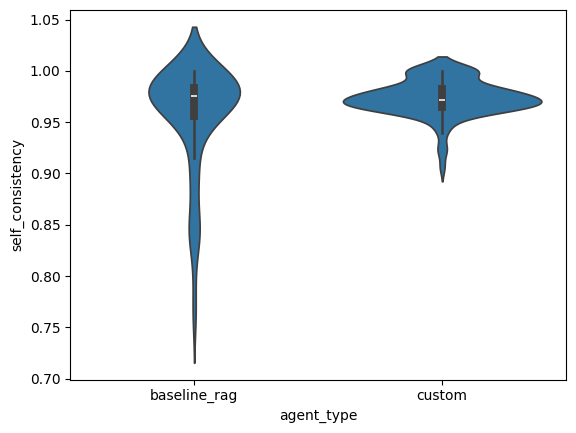

In [48]:
sns.violinplot(embeddings, x = "agent_type", y = "self_consistency")